In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 200)

df_annotators = pd.read_csv("from_annotators.csv")
df_golden = pd.read_csv("hate_speech_gold_sample.csv")

print(df_annotators.shape)
print(df_golden.shape)

df_annotators.head()

(1000, 4)
(1000, 3)


,text,annotator_1,annotator_2,annotator_3
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,No,no,Yes
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",Yes,yes,Yes
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",No,no,Yes
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",No,no,Yes
4,Hate it jab test ata ho phr bh acha na ho -.-,Yes,yes,Yes


In [2]:
df_golden.head()

,Unnamed: 0,text,is_hate_speech
0,0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no
1,1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",no
2,2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no
3,3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",yes
4,4,Hate it jab test ata ho phr bh acha na ho -.-,yes


In [3]:
df_annotators.columns = df_annotators.columns.str.strip().str.lower()
df_golden.columns = df_golden.columns.str.strip().str.lower()

df_golden = df_golden.drop(columns=["unnamed: 0"], errors="ignore")


In [4]:
def normalize_label(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower()

for col in ["annotator_1", "annotator_2", "annotator_3"]:
    df_annotators[col] = df_annotators[col].apply(normalize_label)

df_golden["is_hate_speech"] = df_golden["is_hate_speech"].apply(normalize_label)

In [5]:
df = df_annotators.merge(
    df_golden,
    on="text",
    how="inner"
)

df = df.rename(columns={
    "is_hate_speech": "gold_label"
})

print(df.shape)
df.head()

(1000, 5)


,text,annotator_1,annotator_2,annotator_3,gold_label
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no,no,yes,no
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",yes,yes,yes,no
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no,no,yes,no
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",no,no,yes,yes
4,Hate it jab test ata ho phr bh acha na ho -.-,yes,yes,yes,yes


In [6]:
df.to_csv("merged_data.csv")

In [11]:
df = pd.read_csv("merged_data.csv")
df.drop("Unnamed: 0",axis=1,inplace=True)

In [12]:
df.isnull().sum()


,0
text,1
annotator_1,0
annotator_2,0
annotator_3,0
gold_label,0


In [13]:
df = df.dropna(subset=[
    'text',"annotator_1", "annotator_2", "annotator_3", "gold_label"
])

df["char_len"] = df["text"].apply(len)
df["word_len"] = df["text"].apply(lambda x: len(x.split()))

df[["char_len", "word_len"]].describe()

,char_len,word_len
count,999.000000,999.000000
mean,113.905906,21.301301
std,59.951560,11.288897
min,13.000000,3.000000
25%,69.000000,13.000000
50%,108.000000,20.000000
75%,139.000000,26.500000
max,341.000000,63.000000


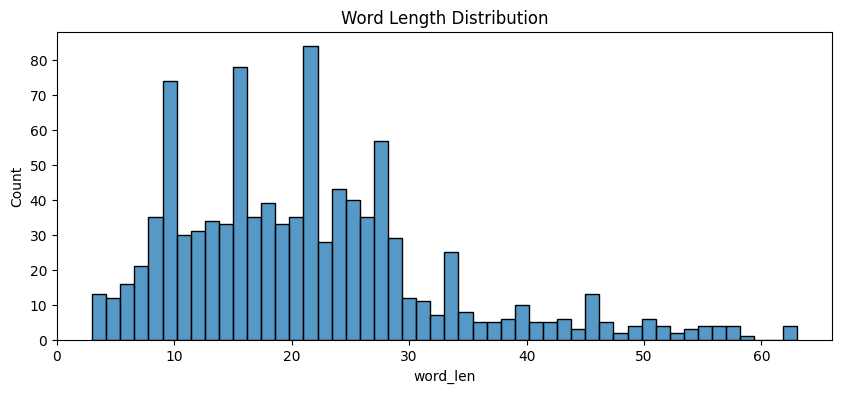

In [14]:
plt.figure(figsize=(10,4))
sns.histplot(df["word_len"], bins=50)
plt.title("Word Length Distribution")
plt.show()

In [15]:
label_cols = ["annotator_1", "annotator_2", "annotator_3", "gold_label"]

for col in label_cols:
    print("\n", col)
    print(df[col].value_counts(normalize=True))


 annotator_1
annotator_1
no     0.527528
yes    0.472472
Name: proportion, dtype: float64

 annotator_2
annotator_2
no     0.620621
yes    0.379379
Name: proportion, dtype: float64

 annotator_3
annotator_3
yes    0.77978
no     0.22022
Name: proportion, dtype: float64

 gold_label
gold_label
no     0.707708
yes    0.292292
Name: proportion, dtype: float64


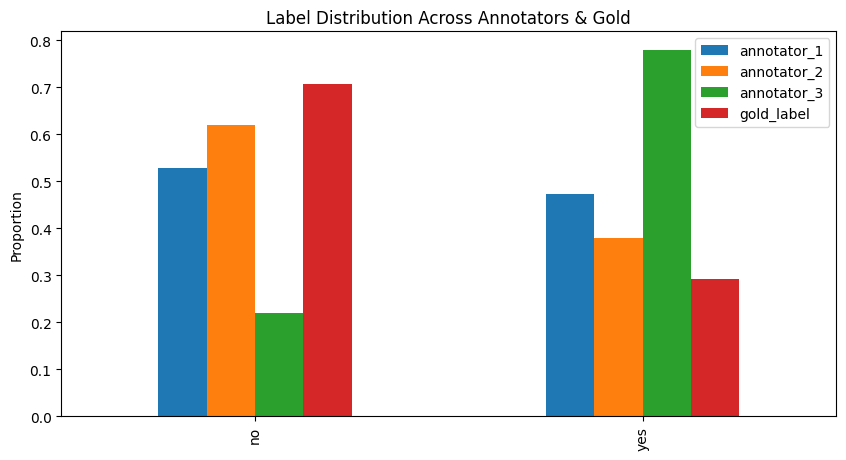

In [16]:
# Label distribution per annotator
label_dist = pd.DataFrame({
    col: df[col].value_counts(normalize=True)
    for col in label_cols
}).fillna(0)

label_dist.plot(kind="bar", figsize=(10,5))
plt.title("Label Distribution Across Annotators & Gold")
plt.ylabel("Proportion")
plt.show()

In [17]:
# Majority vote
df["majority_label"] = df[
    ["annotator_1", "annotator_2", "annotator_3"]
].mode(axis=1)[0]

In [18]:
df["num_yes"] = (
    (df["annotator_1"] == "yes").astype(int) +
    (df["annotator_2"] == "yes").astype(int) +
    (df["annotator_3"] == "yes").astype(int)
)

df["disagreement"] = df["num_yes"].apply(
    lambda x: 1 if x in [1,2] else 0
)

df["disagreement"].value_counts(normalize=True)

,proportion
disagreement,
0,0.562563
1,0.437437


In [19]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\u0900-\u097F\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(5)

,text,clean_text
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",doctor sab sahi me ke phd in hate politics wale bhai padhe likhe ho fir kyu ye sab baate karte ho tum bas bowling khelo aur maje lo pic twitter com fk qubqstw
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",poore desh me patel obc me aate hain sirf gujrat ko chor kar may be ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis obc ko mila hai usse bhi nafrat karte hain ye khoon aur ch...
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",sarkar banne ke bad hindu hit me ek bhi faisla jo bjp ke dwara liya gaya ho bjp ko gay gobar mandir masjid aur nafrat faila kar vot chahiye
4,Hate it jab test ata ho phr bh acha na ho -.-,hate it jab test ata ho phr bh acha na ho


In [20]:
label_map = {"no": 0, "yes": 1}

for col in label_cols + ["majority_label"]:
    df[col + "_bin"] = df[col].map(label_map)

In [21]:
df["label_distribution"] = df.apply(
    lambda row: [
        row["annotator_1_bin"],
        row["annotator_2_bin"],
        row["annotator_3_bin"]
    ],
    axis=1
)

In [22]:
df["gold_vs_majority_mismatch"] = (
    df["gold_label_bin"] != df["majority_label_bin"]
).astype(int)

df["gold_vs_majority_mismatch"].value_counts(normalize=True)

,proportion
gold_vs_majority_mismatch,
0,0.684685
1,0.315315


In [23]:
final_cols = [
    "text",
    "clean_text",
    "annotator_1_bin",
    "annotator_2_bin",
    "annotator_3_bin",
    "gold_label_bin",
    "majority_label_bin",
    "disagreement"
]

final_df = df[final_cols]
final_df.head()

,text,clean_text,annotator_1_bin,annotator_2_bin,annotator_3_bin,gold_label_bin,majority_label_bin,disagreement
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and,0,0,1,0,0,1
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",doctor sab sahi me ke phd in hate politics wale bhai padhe likhe ho fir kyu ye sab baate karte ho tum bas bowling khelo aur maje lo pic twitter com fk qubqstw,1,1,1,0,1,0
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",poore desh me patel obc me aate hain sirf gujrat ko chor kar may be ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis obc ko mila hai usse bhi nafrat karte hain ye khoon aur ch...,0,0,1,0,0,1
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",sarkar banne ke bad hindu hit me ek bhi faisla jo bjp ke dwara liya gaya ho bjp ko gay gobar mandir masjid aur nafrat faila kar vot chahiye,0,0,1,1,0,1
4,Hate it jab test ata ho phr bh acha na ho -.-,hate it jab test ata ho phr bh acha na ho,1,1,1,1,1,0


In [24]:
LABEL_MAP = {
    "yes": 1,
    "no": 0
}

label_cols = ["annotator_1", "annotator_2", "annotator_3", "gold_label"]

for col in label_cols:
    df[col] = df[col].str.strip().str.lower()
    df[col + "_bin"] = df[col].map(LABEL_MAP)

In [25]:
df[label_cols + [c + "_bin" for c in label_cols]].head()

,annotator_1,annotator_2,annotator_3,gold_label,annotator_1_bin,annotator_2_bin,annotator_3_bin,gold_label_bin
0,no,no,yes,no,0,0,1,0
1,yes,yes,yes,no,1,1,1,0
2,no,no,yes,no,0,0,1,0
3,no,no,yes,yes,0,0,1,1
4,yes,yes,yes,yes,1,1,1,1


In [26]:
# Cohen’s Kappa pairwise

from sklearn.metrics import cohen_kappa_score

annotator_pairs = [
    ("annotator_1_bin", "annotator_2_bin"),
    ("annotator_1_bin", "annotator_3_bin"),
    ("annotator_2_bin", "annotator_3_bin"),
]

for a, b in annotator_pairs:
    kappa = cohen_kappa_score(df[a], df[b])
    print(f"Cohen Kappa ({a} vs {b}): {kappa:.4f}")


Cohen Kappa (annotator_1_bin vs annotator_2_bin): 0.7991
Cohen Kappa (annotator_1_bin vs annotator_3_bin): 0.2950
Cohen Kappa (annotator_2_bin vs annotator_3_bin): 0.2733


In [27]:
#fleiss kappa

from statsmodels.stats.inter_rater import fleiss_kappa

def fleiss_matrix(df, cols):
    matrix = []
    for _, row in df[cols].iterrows():
        counts = [0, 0]
        for val in row:
            counts[val] += 1
        matrix.append(counts)
    return np.array(matrix)

fk_matrix = fleiss_matrix(
    df,
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
)

fleiss_kappa(fk_matrix)


np.float64(0.4122237132047699)

In [28]:
!pip install krippendorff

In [29]:
# Krippendorff’s Alpha
import krippendorff

alpha = krippendorff.alpha(
    reliability_data=df[
        ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
    ].values.T,
    level_of_measurement="nominal"
)

alpha

np.float64(0.412419834755252)

In [30]:
from sklearn.metrics import confusion_matrix

for col in ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]:
    cm = confusion_matrix(df["gold_label_bin"], df[col])
    print(f"\nConfusion Matrix: Gold vs {col}")
    print(cm)


Confusion Matrix: Gold vs annotator_1_bin
[[450 257]
 [ 77 215]]

Confusion Matrix: Gold vs annotator_2_bin
[[527 180]
 [ 93 199]]

Confusion Matrix: Gold vs annotator_3_bin
[[202 505]
 [ 18 274]]


In [31]:
df["majority_label_bin"] = df[
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
].mode(axis=1)[0]

In [32]:
df["num_yes"] = df[
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
].sum(axis=1)

df["disagreement"] = df["num_yes"].apply(
    lambda x: 1 if x in [1, 2] else 0
)

df["disagreement"].value_counts(normalize=True)

,proportion
disagreement,
0,0.562563
1,0.437437


In [33]:
ambiguous_cases = df[df["disagreement"] == 1]

ambiguous_cases[
    ["text", "annotator_1", "annotator_2", "annotator_3"]
].head(10)

,text,annotator_1,annotator_2,annotator_3
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no,no,yes
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no,no,yes
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",no,no,yes
5,Ek dil ek jaan akal ke imitihaan kal KP ke rape aur sawing between two legs after rape honge justified due to cinematic liberty aaj toh Rajput ki ho gayi shaan urdu ki gulaam,no,no,yes
6,Aise logo se sakht nafrat karta hu Jo caste ko naam ke sath jod ke chaude hote h but real me vo piddu hote h,no,no,yes
8,I am very sorry to say saaf dil shilpa ke fans hiten ke dil mein kya hai woh bhi samjhte hain hadh hoti hai nafrat ki bhi,no,no,yes
14,Mehanat to school me copy karke likhne me b lagti hai fir illegal kyu? Atanki ko b lagti hai fir nafrat kyu? Paise lekar ghar ki aurato ka smman bech doge kya paise aur mehanat ke liye aap?,no,no,yes
15,"Ladla wo hay jo fard jurm kay bad bhi girftar nahi hota, money trail nahi deta aur saza nahi milti, 14 murder karta hay aur phansi nahi lagti.",no,no,yes
17,Sir ji ab ye possible nahi hai bahut nafrat hai dono or ab ek hi rasta hai sarhad ke lakir ko mita kar hi ye khatam ho sakta hai jinna sahab to mar gaye or neharu ji bhi ab fir se ek kartay hai do...,yes,no,yes
18,"Code phatta hai toh phatne do, Mujhe project se nafrat ho gayi hai, Mujhe development team se hatne do",no,no,yes


In [36]:
datasets = {
    "gold": df[["clean_text", "gold_label_bin"]],
    "annotator_1": df[["clean_text", "annotator_1_bin"]],
    "annotator_2": df[["clean_text", "annotator_2_bin"]],
    "annotator_3": df[["clean_text", "annotator_3_bin"]],
    "majority": df[["clean_text", "majority_label_bin"]],
}

## Base model

In [37]:
!pip install emoji

In [ ]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

import emoji

def extra_features(text):
    return [
        sum(1 for c in text if c in "!?"),
        sum(1 for c in text if c.isupper()),
        emoji.emoji_count(text)
    ]

X_extra = np.array(df["clean_text"].apply(extra_features).tolist())

X_tfidf = tfidf.fit_transform(df["clean_text"])
X = hstack([X_tfidf, X_extra])

models = {
    "svm": LinearSVC(),
    "logreg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(n_estimators=200)
}

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

results = []

for dataset_name, dataset in datasets.items():
    y = dataset.iloc[:, 1].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        p, r, f, _ = precision_recall_fscore_support(
            y_test, preds, average="binary"
        )

        results.append([
            dataset_name, model_name, acc, p, r, f
        ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "dataset",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

results_df

,dataset,model,accuracy,precision,recall,f1
0,gold,svm,0.680,0.440000,0.379310,0.407407
1,gold,logreg,0.740,0.636364,0.241379,0.350000
2,gold,rf,0.760,0.692308,0.310345,0.428571
3,annotator_1,svm,0.920,0.953488,0.872340,0.911111
4,annotator_1,logreg,0.910,0.952381,0.851064,0.898876
5,annotator_1,rf,0.925,1.000000,0.840426,0.913295
6,annotator_2,svm,0.995,1.000000,0.986842,0.993377
7,annotator_2,logreg,0.970,1.000000,0.921053,0.958904
8,annotator_2,rf,0.995,1.000000,0.986842,0.993377
9,annotator_3,svm,0.945,0.944785,0.987179,0.965517


In [ ]:
results_df.groupby(["dataset", "model"]).mean()

accuracy  precision    recall        f1
dataset     model                                          
annotator_1 logreg     0.910   0.952381  0.851064  0.898876
            rf         0.925   1.000000  0.840426  0.913295
            svm        0.920   0.953488  0.872340  0.911111
annotator_2 logreg     0.970   1.000000  0.921053  0.958904
            rf         0.995   1.000000  0.986842  0.993377
            svm        0.995   1.000000  0.986842  0.993377
annotator_3 logreg     0.860   0.847826  1.000000  0.917647
            rf         0.945   0.950311  0.980769  0.965300
            svm        0.945   0.944785  0.987179  0.965517
gold        logreg     0.740   0.636364  0.241379  0.350000
            rf         0.760   0.692308  0.310345  0.428571
            svm        0.680   0.440000  0.379310  0.407407
majority    logreg     0.920   0.986667  0.831461  0.902439
            rf         0.930   1.000000  0.842697  0.914634
            svm        0.885   0.912500  0.820225  0.863905

## Neural networks

In [46]:
import os
import re
import time
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

LOCAL_MODEL_DIR = "./saved_models"
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

MODELS_CONFIG = {
    "mbert": "bert-base-multilingual-cased",
    "xlmr": "xlm-roberta-base"
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def download_models():
    for name, path in MODELS_CONFIG.items():
        save_path = os.path.join(LOCAL_MODEL_DIR, name)
        if not os.path.exists(save_path):
            print(f"Fetching {name}...")
            tokenizer = AutoTokenizer.from_pretrained(path)
            model = AutoModelForSequenceClassification.from_pretrained(path, num_labels=2)
            tokenizer.save_pretrained(save_path)
            model.save_pretrained(save_path)

def hinglish_normalize(text):
    text = str(text).lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    return text.strip()

class HinglishDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1": f1}

def train_and_log(model_key, texts, labels, seed, ann_name):
    print(f"\n{'='*20} PROCESS START {'='*20}")
    print(f"TARGET: {model_key} | LABELS: {ann_name} | SEED: {seed}")

    set_seed(seed)
    model_path = os.path.join(LOCAL_MODEL_DIR, model_key)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2).to(device)

    train_txt, val_txt, train_lbl, val_lbl = train_test_split(
        texts, labels, test_size=0.15, random_state=seed
    )

    t_enc = tokenizer(train_txt, truncation=True, padding=True, max_length=64)
    v_enc = tokenizer(val_txt, truncation=True, padding=True, max_length=64)

    t_ds = HinglishDataset(t_enc, train_lbl)
    v_ds = HinglishDataset(v_enc, val_lbl)

    t_args = TrainingArguments(
        output_dir=f"./results/{model_key}_{seed}",
        num_train_epochs=10,
        per_device_train_batch_size=16,
        eval_strategy="epoch",
        logging_strategy="epoch",
        fp16=torch.cuda.is_available(),
        report_to="none",
        save_strategy="no",
        optim="adamw_torch"
    )

    trainer = Trainer(
        model=model,
        args=t_args,
        train_dataset=t_ds,
        eval_dataset=v_ds,
        compute_metrics=compute_metrics
    )

    start = time.time()
    train_out = trainer.train()
    elapsed = time.time() - start

    print(f"RUNTIME: {elapsed:.2f}s | TRAIN_LOSS: {train_out.training_loss:.4f}")

    return model, tokenizer

def run_full_evaluation(model, tokenizer, texts, labels, ann_name, model_name):
    model.eval()
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model(**inputs)
        preds = torch.argmax(out.logits, dim=1).cpu().numpy()

    print(f"\nMETRICS FOR {model_name} ON {ann_name}:")
    print(classification_report(labels, preds, digits=4))

    cm = confusion_matrix(labels, preds)
    print(f"CONFUSION MATRIX:\n{cm}")

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "tn": cm[0,0], "fp": cm[0,1], "fn": cm[1,0], "tp": cm[1,1]
    }

download_models()

ANNOTATION_SETS = {
    "gold": df["gold_label_bin"].values,
    "majority": df["majority_label_bin"].values,
}

TEXTS = df["clean_text"].apply(hinglish_normalize).tolist()

final_results = []

for name, lbls in ANNOTATION_SETS.items():
    for m_type in MODELS_CONFIG.keys():
        for s in [42, 43]:
            m_trained, t_trained = train_and_log(m_type, TEXTS, lbls, s, name)
            m_stats = run_full_evaluation(m_trained, t_trained, TEXTS, lbls, name, m_type)

            m_stats.update({"annotation": name, "model": m_type, "seed": s})
            final_results.append(m_stats)

output_log = pd.DataFrame(final_results)
output_log.to_csv("reproducibility_full_logs.csv", index=False)


==================== PROCESS START ====================
TARGET: mbert | LABELS: gold | SEED: 42


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.631358,0.585708,0.720000,0.418605
2,0.584154,0.464256,0.853333,0.795031
3,0.541115,0.554675,0.713333,0.416342
4,0.517725,0.395163,0.860000,0.813333
5,0.488644,0.407544,0.846667,0.805513
6,0.455475,0.446833,0.806667,0.776637
7,0.438505,0.467725,0.820000,0.787055
8,0.422548,0.421385,0.853333,0.823113
9,0.347635,0.430460,0.846667,0.818602
10,0.314649,0.432087,0.826667,0.798595


RUNTIME: 68.28s | TRAIN_LOSS: 0.4742

METRICS FOR mbert ON gold:
              precision    recall  f1-score   support

           0     0.9311    0.9180    0.9245       707
           1     0.8079    0.8356    0.8215       292

    accuracy                         0.8939       999
   macro avg     0.8695    0.8768    0.8730       999
weighted avg     0.8951    0.8939    0.8944       999

CONFUSION MATRIX:
[[649  58]
 [ 48 244]]

==================== PROCESS START ====================
TARGET: mbert | LABELS: gold | SEED: 43


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.690560,0.638219,0.660000,0.602618
2,0.360535,0.237349,0.920000,0.918831
3,0.258103,0.273248,0.920000,0.918831
4,0.251659,0.248965,0.920000,0.918831
5,0.256655,0.231921,0.920000,0.918831
6,0.229545,0.320763,0.900000,0.898990
7,0.290435,0.260754,0.920000,0.918831
8,0.189746,0.346891,0.900000,0.898990
9,0.173605,0.374113,0.886667,0.886054
10,0.133040,0.379155,0.906667,0.905593


RUNTIME: 90.09s | TRAIN_LOSS: 0.2834

METRICS FOR xlmr ON majority:
              precision    recall  f1-score   support

           0     0.9381    0.9891    0.9630       552
           1     0.9856    0.9195    0.9514       447

    accuracy                         0.9580       999
   macro avg     0.9619    0.9543    0.9572       999
weighted avg     0.9594    0.9580    0.9578       999

CONFUSION MATRIX:
[[546   6]
 [ 36 411]]

==================== PROCESS START ====================
TARGET: xlmr | LABELS: majority | SEED: 43


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.694790,0.690921,0.626667,0.594907
2,0.427840,0.308448,0.886667,0.885192
3,0.283076,0.338435,0.893333,0.891775
4,0.260516,0.389180,0.893333,0.891775
5,0.258854,0.288582,0.893333,0.891775
6,0.283420,0.371132,0.893333,0.891775
7,0.248342,0.381288,0.906667,0.905593
8,0.300940,0.309230,0.906667,0.905593
9,0.196084,0.361904,0.893333,0.892396
10,0.197008,0.353200,0.906667,0.905593


RUNTIME: 91.38s | TRAIN_LOSS: 0.3151

METRICS FOR xlmr ON majority:
              precision    recall  f1-score   support

           0     0.9150    0.9946    0.9531       552
           1     0.9925    0.8859    0.9362       447

    accuracy                         0.9459       999
   macro avg     0.9537    0.9402    0.9446       999
weighted avg     0.9497    0.9459    0.9455       999

CONFUSION MATRIX:
[[549   3]
 [ 51 396]]


In [48]:
!pip install lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=34ae71da538509f6f0446f9a1f1d1d21613b64a14e67d7616b1bbb7663d2de1b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Human Labeling Reproducibility (Kappa): 0.3406
Interpretation: Fair agreement. High subjectivity in Hinglish hate speech.

--- Results Summary Table ---
annotation model  accuracy  macro_f1  performance_gap
      gold mbert  0.829830  0.797145         0.000000
      gold  xlmr  0.707708  0.414420         0.000000
  majority mbert  0.926927  0.925148         0.128003
  majority  xlmr  0.923924  0.921516         0.507096


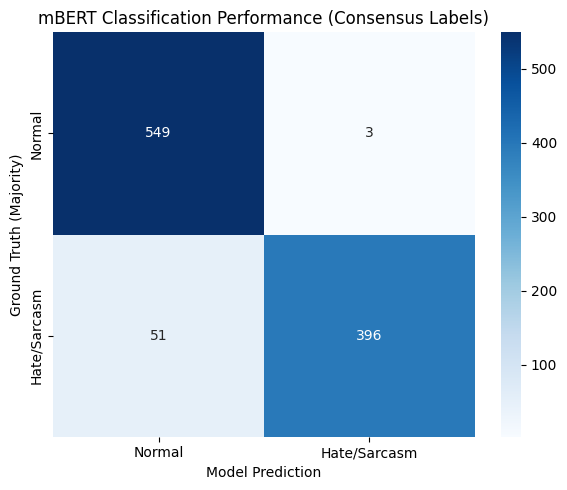


--- Sample Analysis of Ambiguous Text ---
Text: i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and
Human Belief (Normal, Hate): [0.66666667 0.33333333]

Text: poore desh me patel obc me aate hain sirf gujrat ko chor kar may be ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis obc ko mila hai usse bhi nafrat karte hain ye khoon aur chamdi ka frak karne waale bharmhanwadi kisi ke sage nahi hain
Human Belief (Normal, Hate): [0.66666667 0.33333333]

Text: sarkar banne ke bad hindu hit me ek bhi faisla jo bjp ke dwara liya gaya ho bjp ko gay gobar mandir masjid aur nafrat faila kar vot chahiye
Human Belief (Normal, Hate): [0.66666667 0.33333333]



In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
from scipy.spatial.distance import jensenshannon
from lime.lime_text import LimeTextExplainer

def get_human_reproducibility(data):
    kappa = cohen_kappa_score(data["gold_label_bin"], data["majority_label_bin"])
    print(f"Human Labeling Reproducibility (Kappa): {kappa:.4f}")

    if kappa < 0.4:
        print("Interpretation: Fair agreement. High subjectivity in Hinglish hate speech.")
    elif kappa < 0.6:
        print("Interpretation: Moderate agreement.")
    else:
        print("Interpretation: Substantial agreement.")
    return kappa

def plot_final_matrix(stats_dict, title):
    matrix = np.array([
        [stats_dict['tn'], stats_dict['fp']],
        [stats_dict['fn'], stats_dict['tp']]
    ])

    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Hate/Sarcasm'],
                yticklabels=['Normal', 'Hate/Sarcasm'])
    plt.title(title)
    plt.ylabel('Ground Truth (Majority)')
    plt.xlabel('Model Prediction')
    plt.tight_layout()
    plt.show()

def soft_label_analysis(data):
    def soft_calc(row):
        lbls = [row["annotator_1_bin"], row["annotator_2_bin"], row["annotator_3_bin"]]
        return np.bincount(np.array(lbls).astype(int), minlength=2) / 3.0

    data["soft_label"] = data.apply(soft_calc, axis=1)
    data["disagreement_flag"] = data.apply(
        lambda x: 1 if len(set([x.annotator_1_bin, x.annotator_2_bin, x.annotator_3_bin])) > 1 else 0,
        axis=1
    )
    return data

def thesis_summary_table(res_df):
    summary = res_df.groupby(['annotation', 'model']).agg({
        'accuracy': 'mean',
        'macro_f1': 'mean'
    }).reset_index()

    summary['performance_gap'] = summary.groupby('model')['macro_f1'].diff().fillna(0)
    print("\n--- Results Summary Table ---")
    print(summary.to_string(index=False))
    return summary

kappa_val = get_human_reproducibility(df)

df = soft_label_analysis(df)

thesis_table = thesis_summary_table(results_df)

plot_final_matrix(m_stats, "mBERT Classification Performance (Consensus Labels)")

print("\n--- Sample Analysis of Ambiguous Text ---")
ambiguous = df[df["disagreement_flag"] == 1][["clean_text", "soft_label"]].head(3)
for i, row in ambiguous.iterrows():
    print(f"Text: {row['clean_text']}\nHuman Belief (Normal, Hate): {row['soft_label']}\n")